# Perturbation response: does the penalty make the encoder robust to the changes it was chosen for?

This notebook measures how far each trained encoder's latent direction moves when its
input is perturbed by four chemically motivated transforms, across the nine model
configurations selected in `part_4`. It asks the question the whole campaign was built on
and that no earlier notebook actually tested: the Fisher-Rao metric was adopted because
`part_0` found it tracked m/z-shift sensitivity better than the Euclidean one, so after
training under it, are the models measurably harder to displace by an m/z shift.

Prediction quality is settled in `part_1` and `part_4` and is not revisited. The
measurement here is angular, on the latent direction, and it is the one place where a
contractive penalty's stated purpose can succeed or fail on its own terms.

## Introduction

`part_2` and `part_4` measured sensitivity to isotropic noise in the ambient input space.
That is a neutral probe, chosen so neither arm's own geometry was privileged, but it is
not a perturbation any instrument produces. The four transforms here are:

- **m/z shift**, a discrete displacement along the mass axis, which `part_0` identified as
  by far the largest real perturbation mode for this binning and the motivation for
  changing the input metric in the first place;
- **peak broadening**, a loss of instrument resolution;
- **per-bin intensity noise**, modelling local intensity variation such as ion suppression;
- **additive detector noise**, clipped at zero.

Each is applied at full strength and at a sweep of amplitudes along the same direction, so
both the size of the response and its shape in amplitude are available. A penalty that
works should compress the response to at least the transform it was selected against.

### Assumptions

- **The perturbed input is a valid input.** Every transform ends in TIC renormalization,
  matching the dataset's own preprocessing, so the comparison is between two points on the
  same simplex rather than between an input and an off-manifold vector. Perturbations are
  applied to the decoded spectra, after the dataset's normalization, which is the same
  representation the models were trained on.
- **Two transforms are deterministic and two are stochastic.** An m/z shift and a
  broadening are fixed functions of the spectrum, so there is exactly one perturbation per
  pixel and any spread is between pixels. The two noise families are averaged over
  repeated draws with a fixed seed, so their spread mixes pixel variation with draw
  variation; the repeat count is reported.
- **The m/z shift is not circular.** Mass leaving the last bin is discarded rather than
  wrapped to the first, since wraparound has no physical counterpart. The discarded mass is
  measured per transform and reported, because a transform that mostly amputates rather
  than displaces would not mean what its name says.
- **Angles are measured on the normalized latent direction.** Training penalizes the
  Jacobian of the canonical code $u$, while what is measured here is the direction
  $q$ obtained after centering and normalizing. These are different maps, so a penalty that
  succeeds on one need not succeed proportionally on the other; this is the same caveat
  `part_2` records.
- **The amplitude sweep scales the direction, not the transform.** Intermediate amplitudes
  interpolate toward the fully perturbed spectrum rather than re-applying the transform at a
  smaller setting, so the perturbation direction is fixed while its size varies.

### Notation

For a spectrum $x$ on the simplex and a transform $T$, the effective perturbation is
$\delta = T(x)-x$, taken after renormalization, and the amplitude sweep evaluates
$x_t = \mathrm{TIC}(x + t\,\delta)$ for $t \in [0,1]$. The encoder maps an input to the
canonical code $u=(z-\beta)/\gamma$ and thence to the unit direction
$q = Hu/\lVert Hu\rVert$ with $H=I-\mathbf{1}\mathbf{1}^\top/D$. The response is the angle
$\Delta\theta(x,t) = \angle\big(q(x), q(x_t)\big)$, in degrees. A cell is
$c=(\text{geometry},\text{penalty metric},\lambda)$ with repetitions $r=0,\dots,4$.

In [1]:
import hashlib
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.stats import spearmanr

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import sweep_evaluation as evaluation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import perturbations as perturbation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.analysis.autoencoder.latent.sensitivity import (
    canonical_direction, paired_direction_angles,
)
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("perturbation_response")

2026-09-07 17:55:32,287 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 17:55:32,291 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-07 17:55:32,387 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-07 17:55:32,389 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-07 17:55:32,390 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-07 17:55:32,391 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:55:32,407 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-07 17:55:32,533 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 21 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-07 17:55:32,535 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 25 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration and the nine selected cells

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE = WORKSPACE / "models" / MODEL_CONTEXT

ACTIVATION_CAMPAIGN = "fisher-rao-hinge-activation-20260907-01"
FISHER_CAMPAIGN = "fischer-rao-spectral-hinge-experiment-20260906-01"
BASELINE_CAMPAIGN = "bce-baseline-20260905-01"
CAMPAIGNS = [ACTIVATION_CAMPAIGN, FISHER_CAMPAIGN, BASELINE_CAMPAIGN]

BASELINE_CELL = "baseline (no contractive)"
CONTROL_CELLS = [
    "fisher_rao / frobenius / w=1e-05",
    "fisher_rao / spectral / w=1e-05",
]
LADDER_CELLS = [
    "fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=8e-03 / tau=7",
    "fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7",
]
SELECTED_CELLS = [BASELINE_CELL, *CONTROL_CELLS, *LADDER_CELLS]

TARGET_FIELD = "molecule"
BATCH_SIZE = 256
PIXEL_FRACTION = 1.0
SAMPLE_SEED = 42
DECODE_CACHE = Path("data/kidney_workspace/cache/materialized_splits")

# Instrument peak width measured in part_0: median FWHM of 1.00 bin gives sigma = 0.42.
PERTURBATION_SETTINGS = perturbation.PerturbationSettings(
    shift_bins=1, extra_width_sigma=1.0, base_width_sigma=0.42,
    lognormal_sigma=0.05, noise_fraction=0.02,
)
NOISE_REPEATS = 4
AMPLITUDES = (0.0, 0.125, 0.25, 0.5, 0.75, 1.0)
RESPONSE_PIXELS = 2000

ARTIFACT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_5_perturbation_response_results")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

grid_rows = []
for campaign_id in CAMPAIGNS:
    status = WORKSPACE / "configs" / "entropy-runs" / campaign_id / "plan" / "status"
    tasks = read_entropy_campaign(status, MODEL_STORE, load_artifacts=False)
    grid_rows += [
        row for row in sweep.sweep_grid_frame(tasks, campaign_id)
        if row["status"] == "completed" and row["cell_label"] in SELECTED_CELLS
    ]
grid_frame = pd.DataFrame(grid_rows)
missing = sorted(set(SELECTED_CELLS) - set(grid_frame["cell_label"]))
if missing:
    raise KeyError(f"Selected cells absent from the campaigns: {missing}")
print(f"{len(grid_frame)} run(s) across {grid_frame['cell_label'].nunique()} selected cell(s)")

2026-09-07 17:55:32,700 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 20 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fisher-rao-hinge-activation-20260907-01/plan/status'.


2026-09-07 17:55:32,936 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/fisher-rao-hinge-activation-20260907-01/plan/status': 20 task(s) read.


2026-09-07 17:55:32,938 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'fisher-rao-hinge-activation-20260907-01': 20 task(s), 20 completed, 4 distinct grid cell(s).


2026-09-07 17:55:32,939 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 75 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status'.


2026-09-07 17:55:34,040 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status': 75 task(s) read.


2026-09-07 17:55:34,041 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'fischer-rao-spectral-hinge-experiment-20260906-01': 75 task(s), 75 completed, 15 distinct grid cell(s).


2026-09-07 17:55:34,043 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 5 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status'.


2026-09-07 17:55:34,103 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


2026-09-07 17:55:34,104 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'bce-baseline-20260905-01': 5 task(s), 5 completed, 1 distinct grid cell(s).


45 run(s) across 9 selected cell(s)


In [3]:
for campaign_id in (ACTIVATION_CAMPAIGN, FISHER_CAMPAIGN):
    evaluation.link_campaign_scratch_workspace(f"/tmp/ms488923/msi-wrapper/{campaign_id}/workspace", WORKSPACE)

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=grid_frame.iloc[0]["model_name"])
partitions = wrapper.active_dataset.create_partitions()

test_split = evaluation.materialize_split(
    partitions, "test", TARGET_FIELD, fraction=PIXEL_FRACTION, seed=SAMPLE_SEED,
    cache_directory=DECODE_CACHE,
)
# Every model and every amplitude is encoded on the same pixels, drawn once.
response_rng = np.random.default_rng(SAMPLE_SEED)
if test_split.sampled > RESPONSE_PIXELS:
    response_selection = np.sort(response_rng.choice(test_split.sampled, RESPONSE_PIXELS, replace=False))
else:
    response_selection = np.arange(test_split.sampled)
clean_spectra = test_split.spectra[response_selection]
print(f"test split: {test_split.sampled} pixel(s); perturbation response on {len(response_selection)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clean_spectra = clean_spectra.to(device)


def load_model(model_name: str):
    return wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)

2026-09-07 17:55:34,175 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-07 17:55:34,176 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-07 17:55:34,177 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-07 17:55:34,178 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 17:55:34,178 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-07 17:56:12,850 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-09-07 17:56:31,750 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-09-07 17:56:31,895 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


2026-09-07 17:56:33,887 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.sweep_evaluation:263 | Reusing cached split 'test' (4205 pixels) from data/kidney_workspace/cache/materialized_splits/test_f4d4be4539fed078.npz.


test split: 4205 pixel(s); perturbation response on 2000


## Are the perturbations well posed?

### Methodology

#### Theoretical

Before any response is compared, each transform has to be shown to mean what its name
says. Three diagnostics decide that, and each can invalidate a family in a different way:

- **boundary mass lost** is the mass a displacement pushes off the end of the m/z grid.
  A shift that discards a large share of the spectrum is partly an amputation, and its
  response would then measure deletion rather than misalignment;
- **introduced mass** is the mass placed into bins that were empty in the original
  spectrum. A perturbation with large introduced mass leaves the support of the original
  input, which puts it outside the reach of any support-respecting local sensitivity
  measure, including the Fisher-Rao one the models were trained with. This is precisely
  where a finite transform stops being a probe of the trained geometry;
- **input displacement**, $\lVert\delta\rVert_2$, is the size of the perturbation in the
  ambient metric, and is what makes response magnitudes comparable between families.

#### Implementation

`perturb_spectra` applies each family to the shared pixel sample and returns the three
diagnostics with the perturbed spectra. The stochastic families draw from a seeded
generator; the reported values are for the first draw, since the diagnostics describe the
transform rather than a particular realization.

#### Figure descriptions

The table lists one row per family with a flag for whether it is deterministic, and the
mean and maximum of the three diagnostics. Boundary mass lost and introduced mass are
fractions of the renormalized spectrum, so they are directly readable as shares. A family
whose introduced mass is a substantial share carries the caveat above.

### Remarks

### Notes

In [4]:
perturbation_generator = torch.Generator(device="cpu").manual_seed(SAMPLE_SEED + 400)
applied = {
    name: perturbation.perturb_spectra(
        clean_spectra, name, settings=PERTURBATION_SETTINGS, generator=perturbation_generator,
    )
    for name in perturbation.PERTURBATION_NAMES
}
diagnostics_frame = pd.DataFrame(perturbation.perturbation_diagnostics_frame(applied))
display(diagnostics_frame.round(5))

2026-09-07 17:56:34,337 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.latent.perturbations:271 | Summarized 4 perturbation family diagnostics.


,perturbation,deterministic,mean_boundary_mass_lost,max_boundary_mass_lost,mean_introduced_mass,max_introduced_mass,mean_input_displacement,max_input_displacement
0,mz_shift,True,0.00007,0.00181,0.46675,1.00000,0.17377,0.77377
1,width_jitter,True,0.00019,0.00281,0.25743,0.62395,0.08827,0.39545
2,intensity_lognormal,False,0.00000,0.00000,0.00000,0.00000,0.00592,0.02627
3,additive_noise,False,0.00000,0.00000,0.00390,0.00832,0.00093,0.00373


## Angular response at full perturbation

### Methodology

#### Theoretical

The primary measurement. For each model and each family, the canonical latent direction is
computed for the clean and the fully perturbed spectra and the angle between them recorded
per pixel. The contractive penalty exists to make this angle small; whether it does, and
for which family, is the question.

The comparison of interest is against the baseline within a family, not between families.
Families differ in their input displacement by construction, so a smaller angle under one
family than another says nothing about the encoder.

For the two stochastic families the angle is averaged over `NOISE_REPEATS` independent
draws per pixel before any aggregation, so the pixel remains the sampling unit and the
draw-to-draw variation does not inflate the apparent spread across pixels.

#### Implementation

Directions come from `canonical_direction`, which undoes the bottleneck affine and
normalizes the centered code, and angles from `paired_direction_angles`, which uses a
half-angle formula that stays accurate for the small angles the weaker perturbations
produce. Both are the functions `part_0` used, so the measurement convention is unchanged
across the campaign. Every model sees the identical pixels and, for the stochastic
families, the identical noise draws.

#### Figure descriptions

One panel per perturbation family, named in the panel title. The x-axis lists the nine
cells in the order baseline, controls, then the hinge ladder by increasing weight; the
y-axis is the mean angular displacement in degrees on a logarithmic scale, one value per
pixel. Each violin is the distribution over pixels for the cell's first repetition and the
overlaid points are a fixed subsample, drawn with a seeded generator, since one point per
pixel is unreadable; the violin itself uses every pixel. The dashed line is the baseline's
median. Lower means a less perturbable encoder, which is the penalty's intended effect.

### Remarks

### Notes

In [5]:
def canonical_directions(model, spectra: torch.Tensor) -> torch.Tensor:
    """Encode in batches and return the unit latent direction per spectrum."""
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    gamma_tensor = torch.as_tensor(gamma, device=spectra.device)
    beta_tensor = torch.as_tensor(beta, device=spectra.device)
    directions = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            latent = model(spectra[start : start + BATCH_SIZE])["latent_space"]  # (B, D)
            directions.append(canonical_direction(latent, gamma_tensor, beta_tensor)[1])
    return torch.cat(directions)  # (N, D)


# Fixed noise realizations, shared by every model so the comparison is paired on the draw.
repeat_generator = torch.Generator(device="cpu").manual_seed(SAMPLE_SEED + 500)
perturbed_by_family = {}
for name in perturbation.PERTURBATION_NAMES:
    repeats = NOISE_REPEATS if name not in perturbation.DETERMINISTIC_PERTURBATIONS else 1
    perturbed_by_family[name] = [
        perturbation.perturb_spectra(
            clean_spectra, name, settings=PERTURBATION_SETTINGS, generator=repeat_generator,
        ).spectra
        for _ in range(repeats)
    ]
print({name: len(draws) for name, draws in perturbed_by_family.items()})

response_rows = []
for position, record in enumerate(grid_frame.to_dict("records"), start=1):
    model = load_model(record["model_name"])
    model.eval()
    clean_direction = canonical_directions(model, clean_spectra)  # (N, D)
    for name, draws in perturbed_by_family.items():
        # `paired_direction_angles` returns radians; the mean is taken over draws
        # before conversion so the pixel stays the sampling unit.
        angles = torch.stack([
            paired_direction_angles(clean_direction, canonical_directions(model, draw))
            for draw in draws
        ]).mean(dim=0)  # (N,) radians
        degrees = np.degrees(angles.cpu().numpy())  # (N,)
        for pixel_index, value in enumerate(degrees):
            response_rows.append({
                "cell_label": record["cell_label"], "campaign": record["campaign"],
                "penalty_metric": record["penalty_metric"], "weight": record["weight"],
                "repetition": record["repetition"], "perturbation": name,
                "pixel": int(response_selection[pixel_index]), "angle_degrees": float(value),
            })
    if position % 10 == 0 or position == len(grid_frame):
        logger.info("Perturbation response: %s/%s model(s).", position, len(grid_frame))

response_frame = pd.DataFrame(response_rows)
print(f"{len(response_frame)} response row(s)")

{'mz_shift': 1, 'width_jitter': 1, 'intensity_lognormal': 4, 'additive_noise': 4}
2026-09-07 17:56:34,702 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:56:34,703 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-07 17:56:34,704 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-07 17:56:34,704 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-09-07 17:56:34,709 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-09-07 17:57:05,770 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-07 17:57:05,773 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:57:05,777 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


2026-09-07 17:57:06,451 | INFO     | perturbation_response:48 | Perturbation response: 45/45 model(s).


360000 response row(s)


perturbation,additive_noise,intensity_lognormal,mz_shift,width_jitter
cell_label,,,,
baseline (no contractive),0.0888,0.7975,33.5377,13.8956
fisher_rao / frobenius / w=1e-05,0.0873,0.7911,35.1163,14.9083
fisher_rao / spectral / w=1e-05,0.0897,0.8028,31.1821,13.3045
fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7,0.0900,0.7864,31.6093,11.6920
fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7,0.0931,0.7870,26.9190,11.5359
fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7,0.0949,0.7771,25.0108,10.7804
fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7,0.0939,0.7607,25.1963,10.8523
fisher_rao / spectral_plus_hinged / w=8e-03 / tau=7,0.0948,0.7442,23.5380,9.3564
fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7,0.0955,0.7377,24.8381,10.1502


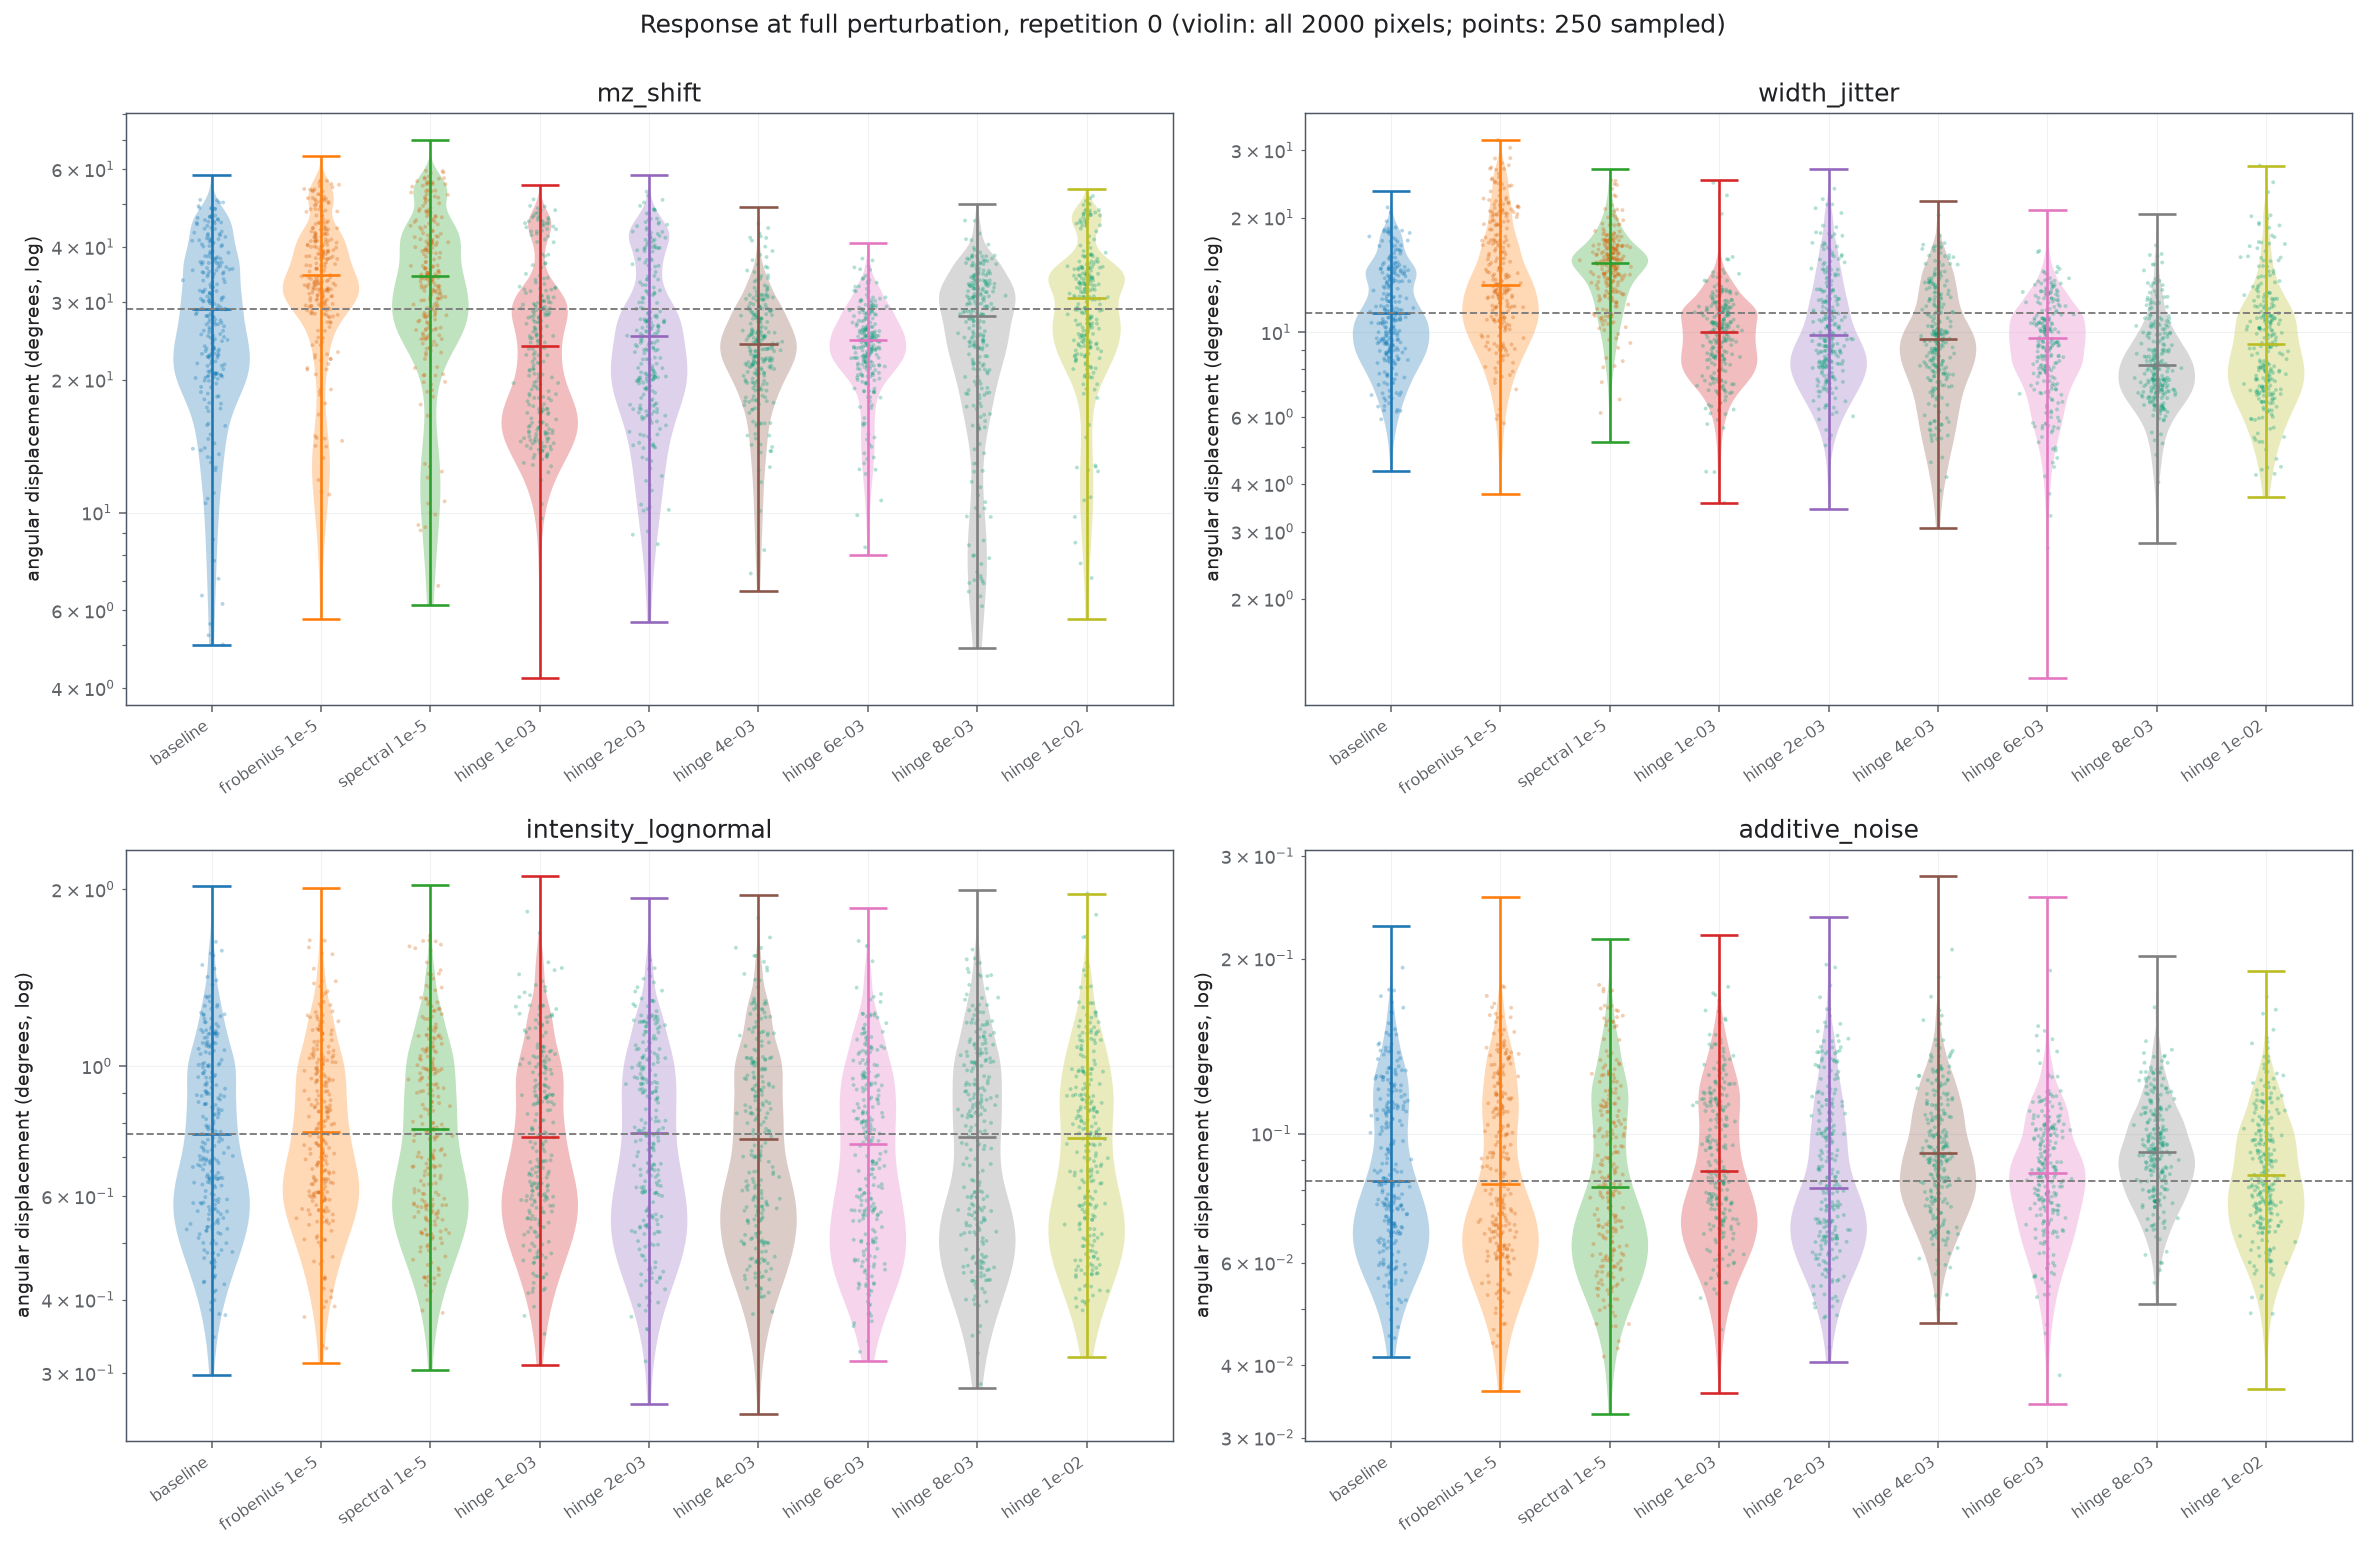

In [6]:
GROUP_COLOR = {
    "baseline": theme.color_for_model("baseline", 0),
    "control": theme.color_for_model("control", 1),
    "ladder": theme.color_for_model("ladder", 2),
}
def cell_group(cell):
    if cell == BASELINE_CELL:
        return "baseline"
    return "control" if cell in CONTROL_CELLS else "ladder"
CELL_COLOR = {cell: GROUP_COLOR[cell_group(cell)] for cell in SELECTED_CELLS}
SHORT_LABEL = {
    BASELINE_CELL: "baseline",
    "fisher_rao / frobenius / w=1e-05": "frobenius 1e-5",
    "fisher_rao / spectral / w=1e-05": "spectral 1e-5",
    **{cell: f"hinge {cell.split('w=')[1].split(' /')[0]}" for cell in LADDER_CELLS},
}
POINT_SAMPLE = 250

point_rng = np.random.default_rng(SAMPLE_SEED + 9)
first_repetition = response_frame.query("repetition == 0")
figure, axes = plt.subplots(2, 2, figsize=(17.0, 11.0), dpi=theme.figure_dpi)
for axis, name in zip(axes.ravel(), perturbation.PERTURBATION_NAMES):
    family = first_repetition.query("perturbation == @name")
    samples = {cell: group["angle_degrees"].to_numpy() for cell, group in family.groupby("cell_label")}
    for position, cell in enumerate(SELECTED_CELLS):
        values = samples.get(cell)
        if values is None or not len(values):
            continue
        axis.violinplot([values], positions=[position], widths=0.7, showmedians=True)
        shown = values if len(values) <= POINT_SAMPLE else point_rng.choice(values, POINT_SAMPLE, replace=False)
        axis.scatter(
            position + point_rng.normal(0.0, 0.07, size=len(shown)), shown,
            color=CELL_COLOR[cell], s=4, alpha=0.3, edgecolor="none",
        )
    if BASELINE_CELL in samples:
        axis.axhline(float(np.median(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1)
    axis.set_yscale("log")
    axis.set_xticks(range(len(SELECTED_CELLS)))
    axis.set_xticklabels([SHORT_LABEL[cell] for cell in SELECTED_CELLS], rotation=35, ha="right", fontsize=8)
    axis.set(ylabel="angular displacement (degrees, log)", title=name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle(f"Response at full perturbation, repetition 0 (violin: all {len(response_selection)} pixels; points: {POINT_SAMPLE} sampled)", y=1.001, fontsize=13)
figure.tight_layout()

display(
    response_frame.pivot_table(index="cell_label", columns="perturbation", values="angle_degrees", aggfunc="median")
    .reindex(SELECTED_CELLS).round(4)
)

## Robustness against the baseline, per perturbation family

### Methodology

#### Theoretical

The headline question in a single number per cell and family: does the penalty reduce the
angular response relative to an unregularized model trained on the same split. Because
repetitions of two cells share their split and dataloader seeds and differ only in run
seeds, the comparison is paired on repetition, which removes the between-seed variance that
would otherwise dominate five observations.

The per-repetition statistic is the median pixel response rather than the mean, because the
distributions are heavy-tailed on a log scale and a mean would follow the tail rather than
the typical pixel.

A negative difference means the penalized model moves less than the baseline, which is the
intended direction. The two control cells provide the null band: they are configurations
earlier notebooks found inert, so their contrasts show what no effect looks like.

#### Implementation

`paired_contrast` matches repetitions by index and reports a two-sided 95% Student-t
interval on the paired differences. It is applied per family independently, since a penalty
could compress one perturbation mode and not another, which is exactly the hypothesis the
input-metric change was based on.

#### Figure descriptions

One panel per family. The x-axis lists the eight non-baseline cells and the y-axis the
paired difference in median angular displacement against the baseline, in degrees; the
horizontal line at zero is the baseline. Error bars are the 95% intervals and a marker with
a black edge is a cell whose interval excludes zero. Points below zero are more robust than
the baseline, points above less robust.

### Remarks

### Notes

,perturbation,cell_label,pairs,mean_difference,ci_low,ci_high,separated_from_zero
0,mz_shift,fisher_rao / frobenius / w=1e-05,5,0.9838,-7.9234,9.8910,False
1,mz_shift,fisher_rao / spectral / w=1e-05,5,-2.2010,-9.6609,5.2589,False
2,mz_shift,fisher_rao / spectral_plus_hinged / w=1e-03 / ...,5,-0.8555,-8.1295,6.4184,False
3,mz_shift,fisher_rao / spectral_plus_hinged / w=2e-03 / ...,5,-6.4959,-8.8109,-4.1809,True
4,mz_shift,fisher_rao / spectral_plus_hinged / w=4e-03 / ...,5,-8.4104,-16.4683,-0.3524,True
5,mz_shift,fisher_rao / spectral_plus_hinged / w=6e-03 / ...,5,-6.4926,-18.2375,5.2524,False
6,mz_shift,fisher_rao / spectral_plus_hinged / w=8e-03 / ...,5,-9.8313,-17.1296,-2.5331,True
7,mz_shift,fisher_rao / spectral_plus_hinged / w=1e-02 / ...,5,-7.8290,-17.3250,1.6670,False
8,width_jitter,fisher_rao / frobenius / w=1e-05,5,0.6635,-2.4504,3.7774,False
9,width_jitter,fisher_rao / spectral / w=1e-05,5,-0.6510,-4.2793,2.9772,False


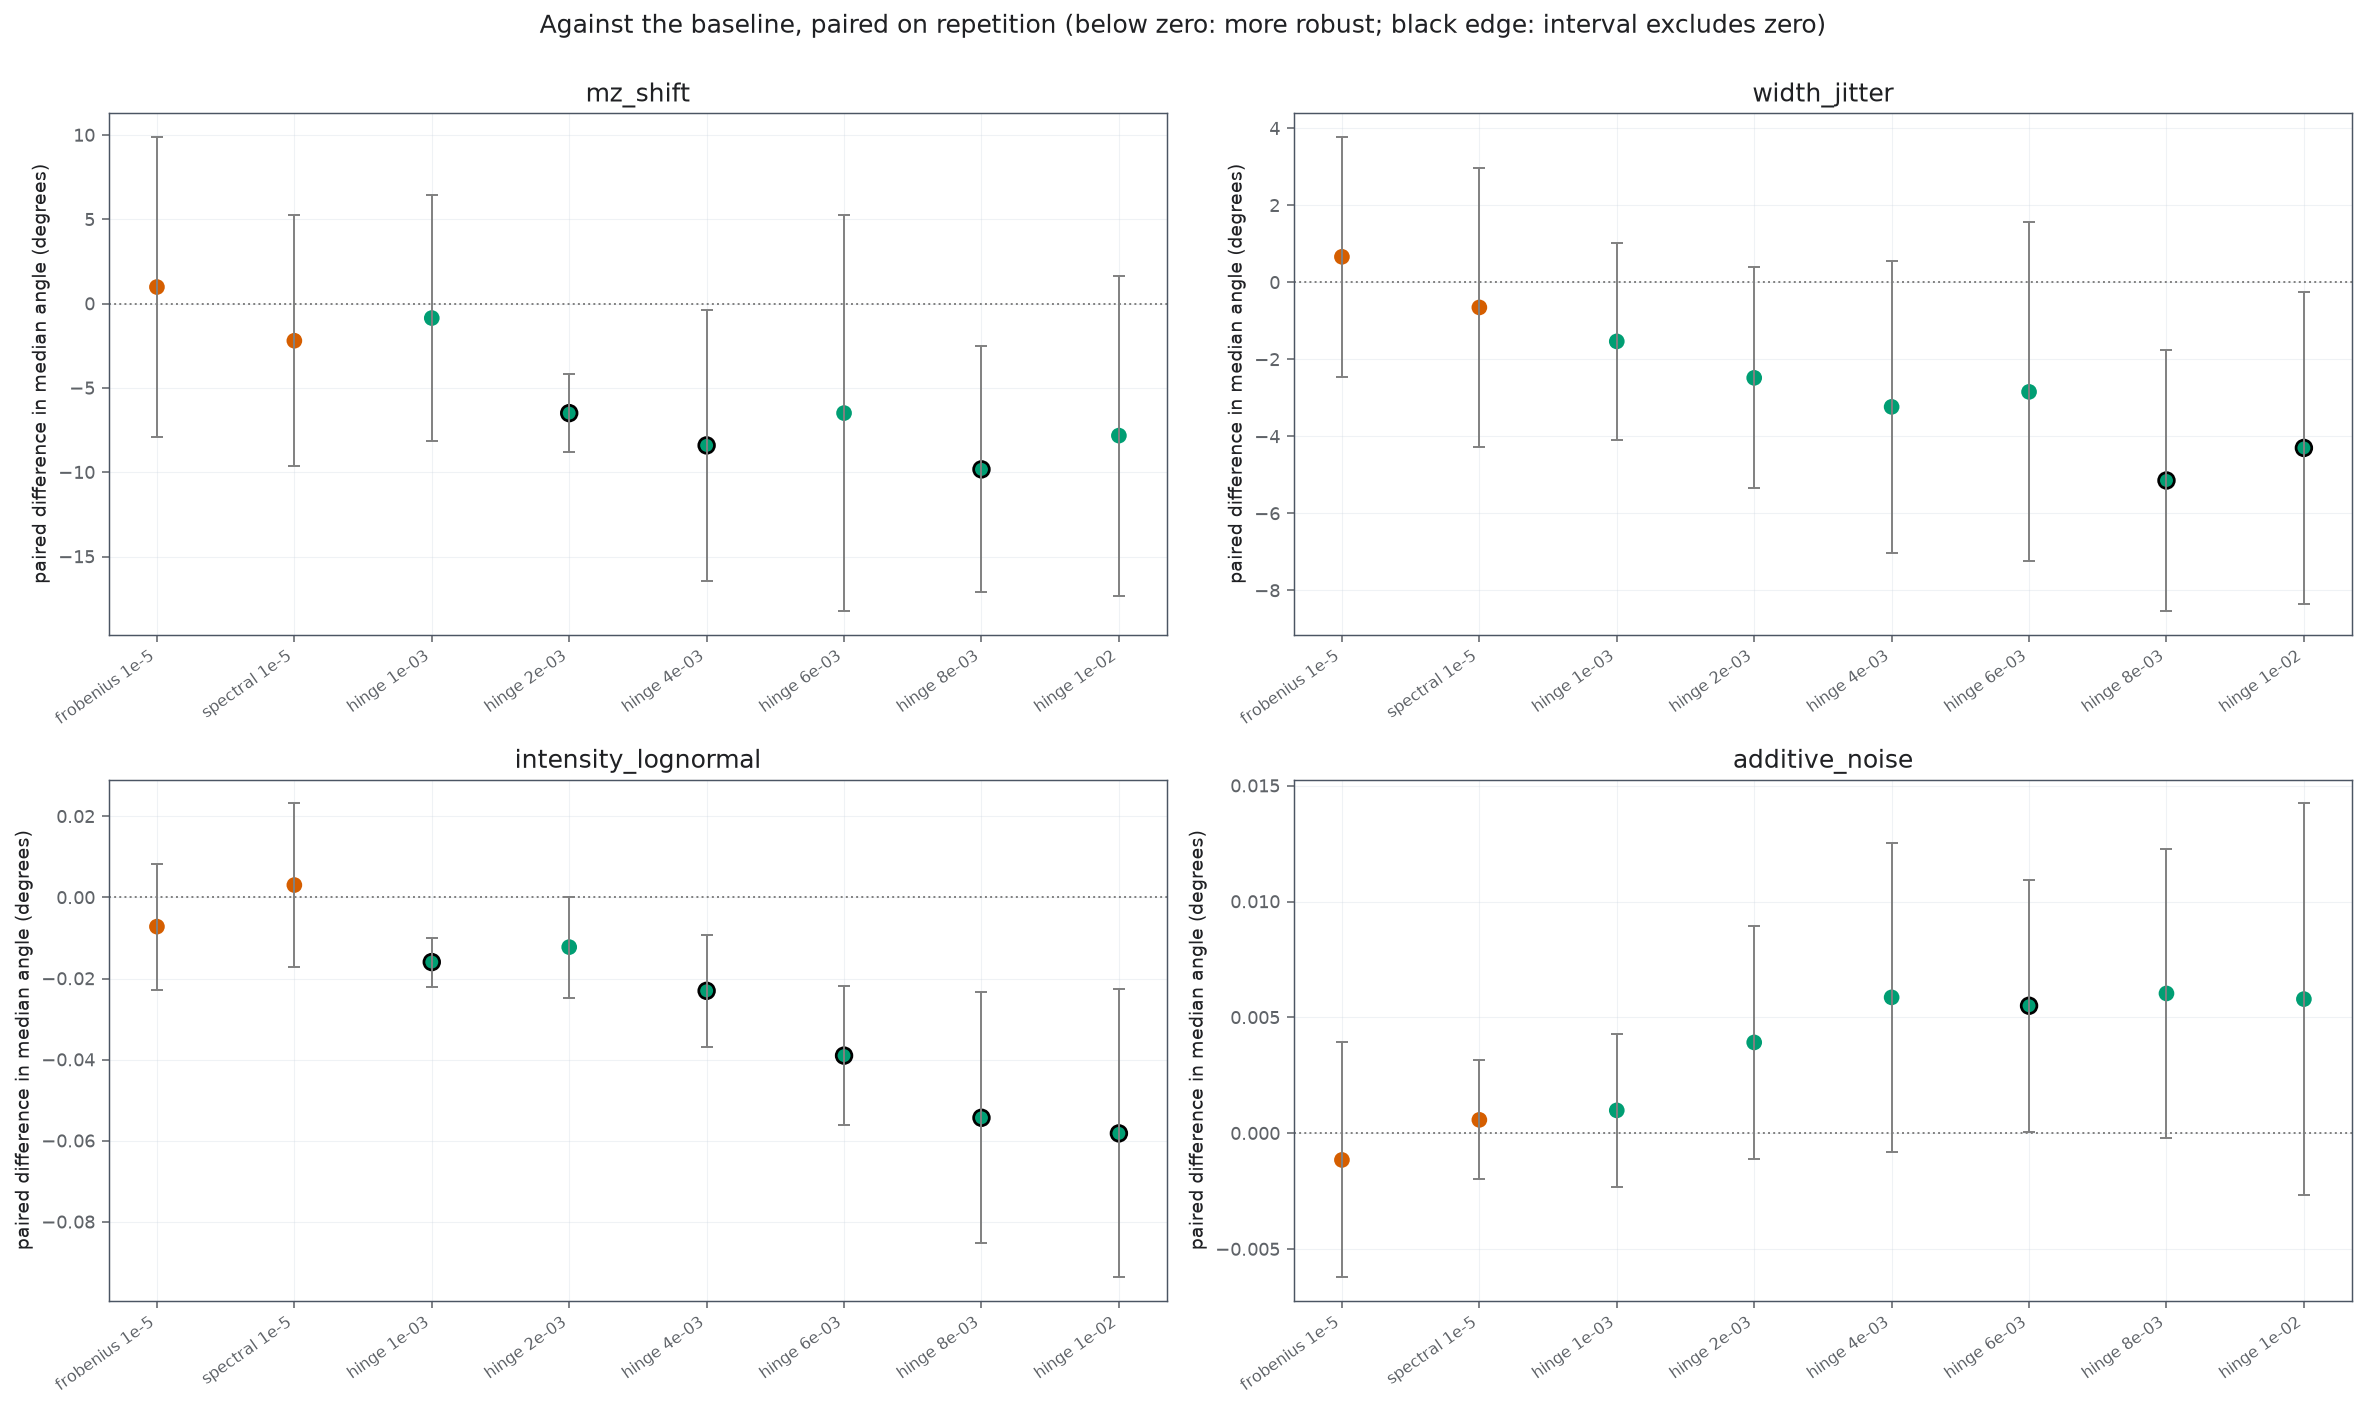

In [7]:
median_by_run = (
    response_frame.groupby(["cell_label", "repetition", "perturbation"])["angle_degrees"]
    .median().reset_index()
)


def repetition_map(cell, name):
    selected = median_by_run.query("cell_label == @cell and perturbation == @name")
    return {int(row.repetition): float(row.angle_degrees) for row in selected.itertuples()}


contrast_rows = []
for name in perturbation.PERTURBATION_NAMES:
    reference = repetition_map(BASELINE_CELL, name)
    for cell in SELECTED_CELLS:
        if cell == BASELINE_CELL:
            continue
        contrast = sweep.paired_contrast(repetition_map(cell, name), reference)
        contrast_rows.append({"perturbation": name, "cell_label": cell, **contrast})
contrast_frame = pd.DataFrame(contrast_rows)

figure, axes = plt.subplots(2, 2, figsize=(17.0, 10.0), dpi=theme.figure_dpi)
non_baseline = [cell for cell in SELECTED_CELLS if cell != BASELINE_CELL]
for axis, name in zip(axes.ravel(), perturbation.PERTURBATION_NAMES):
    family = contrast_frame.query("perturbation == @name").set_index("cell_label").reindex(non_baseline).dropna(subset=["mean_difference"])
    positions = np.arange(len(family))
    axis.errorbar(
        positions, family["mean_difference"],
        yerr=[family["mean_difference"] - family["ci_low"], family["ci_high"] - family["mean_difference"]],
        fmt="none", ecolor="grey", elinewidth=1, capsize=3,
    )
    axis.scatter(
        positions, family["mean_difference"], s=65,
        color=[CELL_COLOR[cell] for cell in family.index],
        edgecolor=["black" if separated else "none" for separated in family["separated_from_zero"]], linewidth=1.4,
    )
    axis.axhline(0.0, color="grey", linestyle=":", linewidth=1)
    axis.set_xticks(positions)
    axis.set_xticklabels([SHORT_LABEL[cell] for cell in family.index], rotation=35, ha="right", fontsize=8)
    axis.set(ylabel="paired difference in median angle (degrees)", title=name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Against the baseline, paired on repetition (below zero: more robust; black edge: interval excludes zero)", y=1.001, fontsize=13)
figure.tight_layout()
display(contrast_frame.round(4))

## Response as a function of perturbation amplitude

### Methodology

#### Theoretical

A single full-strength number cannot distinguish two situations that differ for a
regularizer: an encoder whose response is uniformly smaller, and one whose response is
merely delayed and then rises just as steeply. Sweeping the amplitude along a fixed
direction separates them. A contractive penalty bounds the local slope, so if it works its
effect should be largest at small amplitudes and may vanish at large ones, where the
perturbation leaves the neighbourhood the penalty controls.

#### Implementation

Amplitudes interpolate between the clean and the fully perturbed spectrum, so the direction
is fixed and only its length varies; the interpolated spectrum is renormalized to stay on
the simplex. The zero-amplitude point is evaluated rather than assumed, as a check that the
angle is exactly zero there and the pipeline introduces no spurious displacement. To keep
the model count tractable the sweep uses repetition 0 of each cell and the deterministic
families plus one draw of each stochastic family.

#### Figure descriptions

One panel per family. The x-axis is the perturbation amplitude and the y-axis the median
angular displacement in degrees across pixels, both on logarithmic scales, with the
zero-amplitude point omitted from the log axis and reported separately as a numeric check.
Each line is one cell, colored by group. A curve lying below another is a more robust
encoder at that amplitude; curves that converge at the right show a penalty whose effect is
local.

### Remarks

### Notes

2026-09-07 17:57:09,731 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:57:09,732 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-07 17:57:09,732 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-07 17:57:09,733 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-09-07 17:57:09,736 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-09-07 17:57:22,120 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-07 17:57:22,121 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-07 17:57:22,124 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 17:57:22,129 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


Zero-amplitude angular residual: 9.66e-06 degrees


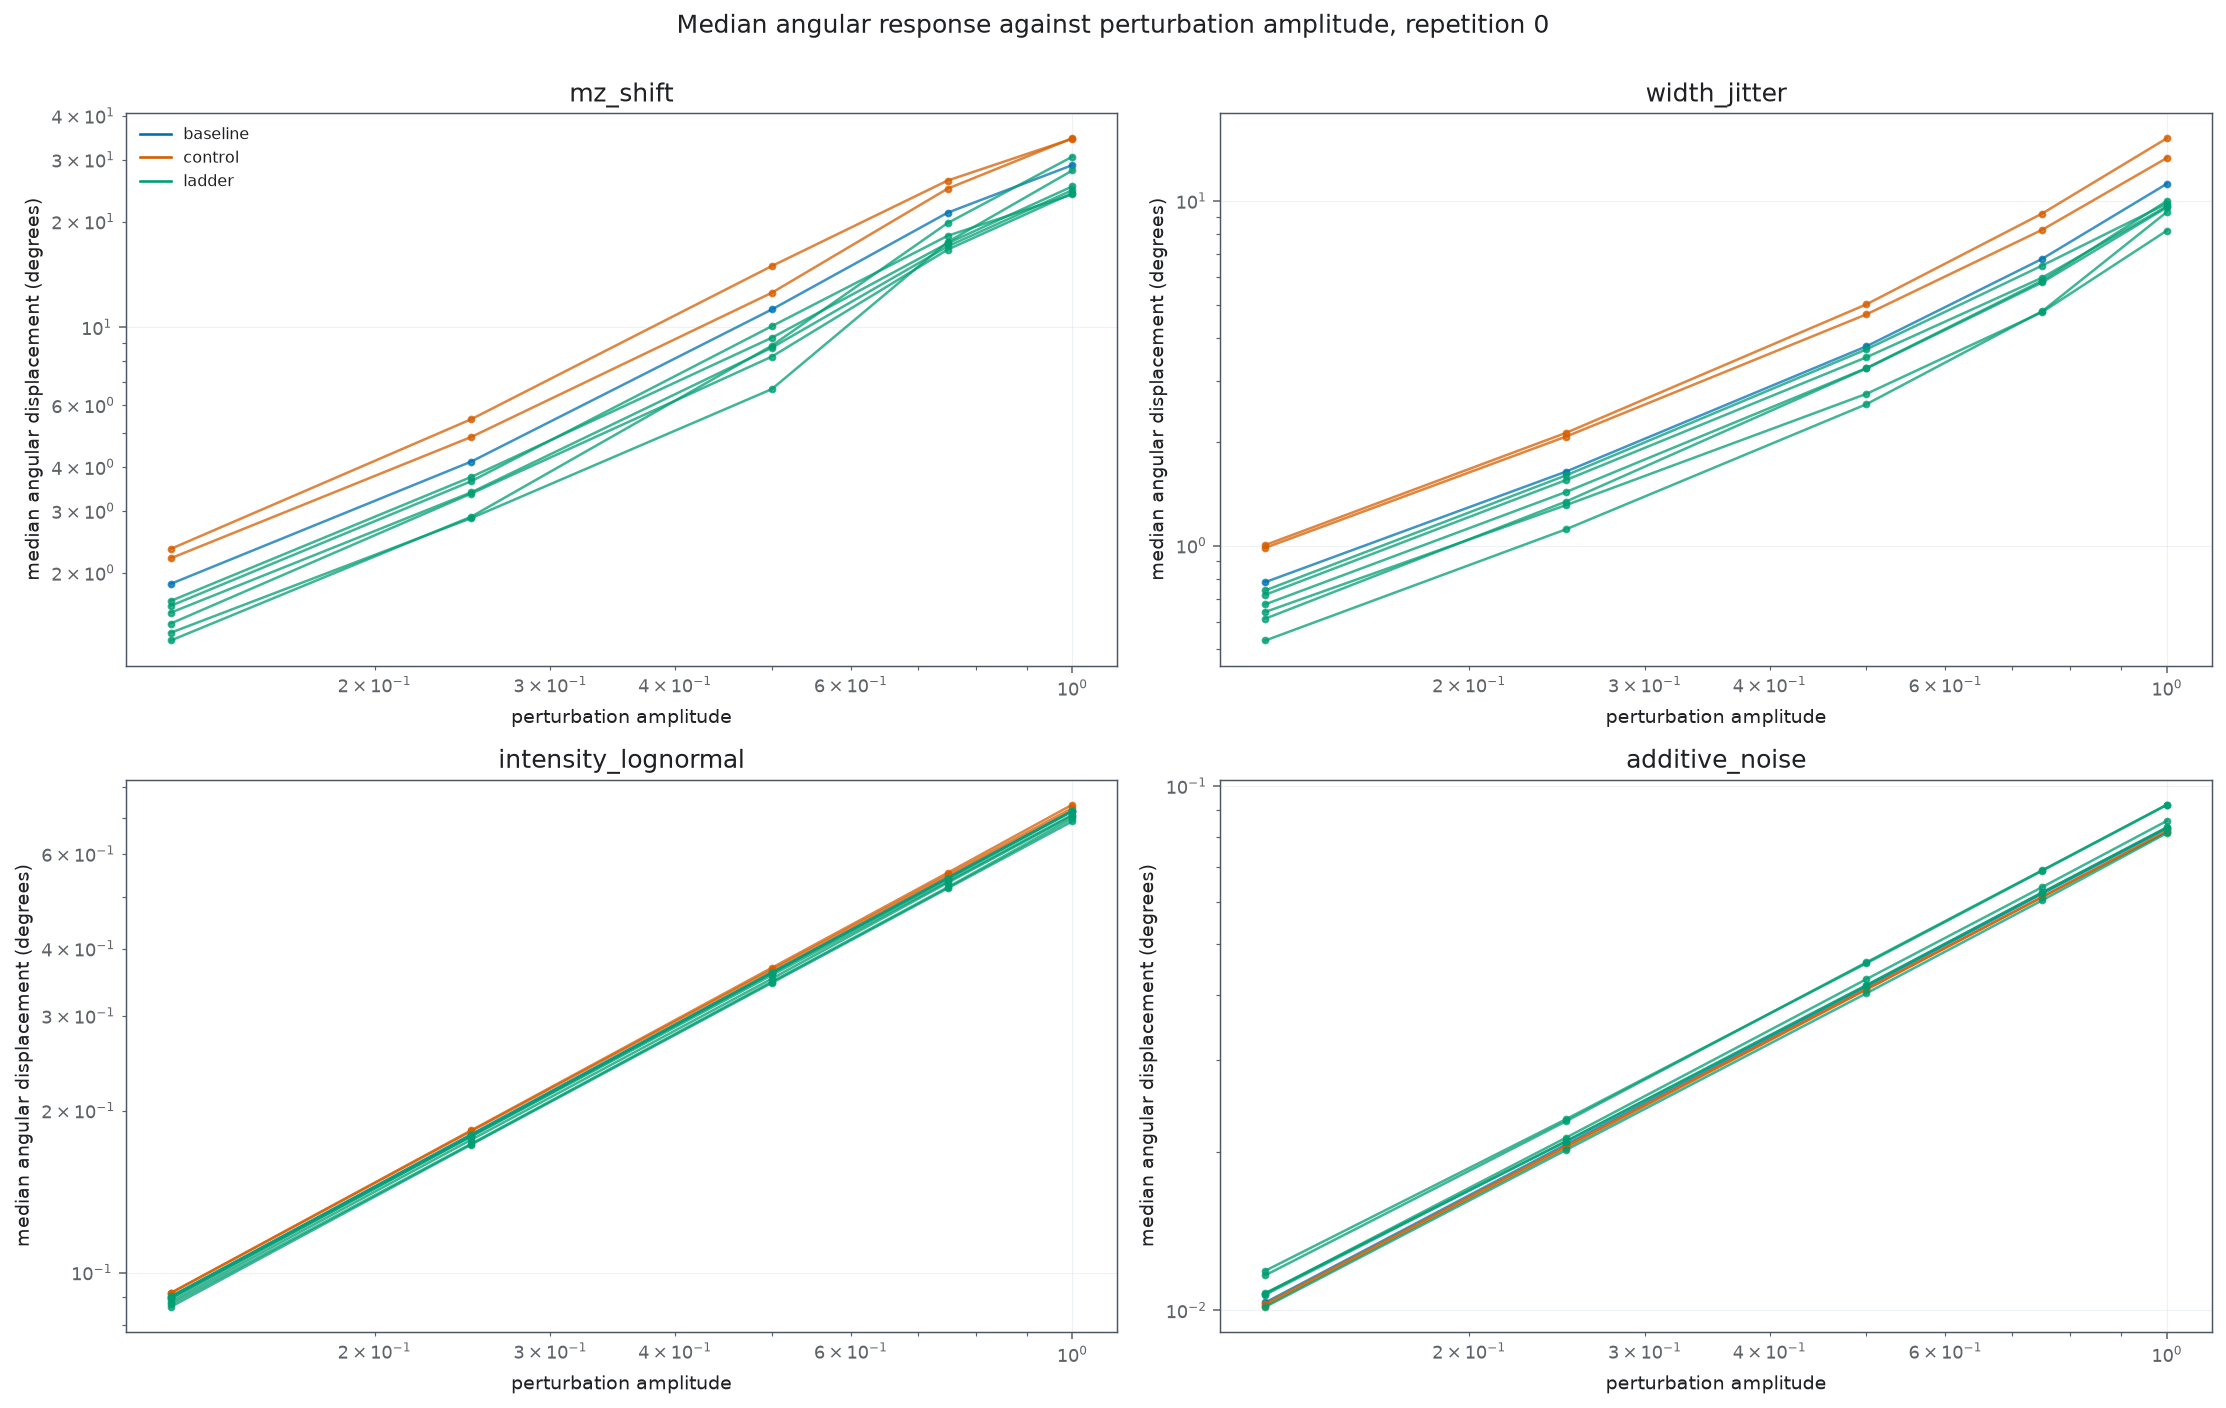

In [8]:
amplitude_rows = []
sweep_families = {
    name: draws[0] for name, draws in perturbed_by_family.items()
}
for record in grid_frame.query("repetition == 0").to_dict("records"):
    model = load_model(record["model_name"])
    model.eval()
    clean_direction = canonical_directions(model, clean_spectra)
    for name, perturbed in sweep_families.items():
        for amplitude in AMPLITUDES:
            blended = perturbation.interpolate_perturbation(clean_spectra, perturbed, amplitude)
            angles = paired_direction_angles(clean_direction, canonical_directions(model, blended))
            values = np.degrees(angles.cpu().numpy())  # (N,)
            amplitude_rows.append({
                "cell_label": record["cell_label"], "perturbation": name, "amplitude": float(amplitude),
                "median_angle_degrees": float(np.median(values)),
                "mean_angle_degrees": float(np.mean(values)),
            })
amplitude_frame = pd.DataFrame(amplitude_rows)

zero_residual = amplitude_frame.query("amplitude == 0")["mean_angle_degrees"].abs().max()
print(f"Zero-amplitude angular residual: {zero_residual:.3g} degrees")

figure, axes = plt.subplots(2, 2, figsize=(16.0, 10.0), dpi=theme.figure_dpi)
positive = amplitude_frame.query("amplitude > 0")
for axis, name in zip(axes.ravel(), perturbation.PERTURBATION_NAMES):
    family = positive.query("perturbation == @name")
    for cell, group in family.groupby("cell_label"):
        group = group.sort_values("amplitude")
        axis.plot(
            group["amplitude"], group["median_angle_degrees"],
            color=CELL_COLOR[cell], alpha=0.75, linewidth=1.3,
            marker="o", markersize=3,
        )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set(xlabel="perturbation amplitude", ylabel="median angular displacement (degrees)", title=name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
handles = [plt.Line2D([], [], color=color, label=group) for group, color in GROUP_COLOR.items()]
axes.ravel()[0].legend(handles=handles, fontsize=8, frameon=theme.legend_frame)
figure.suptitle("Median angular response against perturbation amplitude, repetition 0", y=1.001, fontsize=13)
figure.tight_layout()

## Is robustness perturbation-specific or general?

### Methodology

#### Theoretical

The input metric was changed because `part_0` found that the Fisher-Rao operator tracked
m/z-shift sensitivity specifically, and that its advantage over the Euclidean one did not
extend to peak broadening. If that specificity survives training, the models should not
order identically across families: a model most robust to m/z shift need not be most robust
to intensity noise. If instead every family ranks the cells the same way, the penalty is
compressing the encoder uniformly rather than along the direction it was chosen for, and the
metric argument gains no support from the trained models.

The check is a rank correlation between families over cells, using each cell's median
response. Rank rather than value because families differ in scale by construction.

#### Implementation

Spearman correlation between every pair of families across the nine cells, computed on the
per-cell medians pooled over repetitions.

#### Figure descriptions

The matrix reports Spearman correlation between families across the nine cells. A value near
one means the two families order the cells identically, so robustness to one implies
robustness to the other; a low or negative value means the effect is family-specific. The
scatter panels below plot, for each family against m/z shift, one point per cell with its
median response on both axes on logarithmic scales, so the ordering can be inspected
directly rather than only through the coefficient.

### Remarks

### Notes

perturbation,mz_shift,width_jitter,intensity_lognormal,additive_noise
cell_label,,,,
baseline (no contractive),33.5377,13.8956,0.7975,0.0888
fisher_rao / frobenius / w=1e-05,35.1163,14.9083,0.7911,0.0873
fisher_rao / spectral / w=1e-05,31.1821,13.3045,0.8028,0.0897
fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7,31.6093,11.6920,0.7864,0.0900
fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7,26.9190,11.5359,0.7870,0.0931
fisher_rao / spectral_plus_hinged / w=4e-03 / tau=7,25.0108,10.7804,0.7771,0.0949
fisher_rao / spectral_plus_hinged / w=6e-03 / tau=7,25.1963,10.8523,0.7607,0.0939
fisher_rao / spectral_plus_hinged / w=8e-03 / tau=7,23.5380,9.3564,0.7442,0.0948
fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7,24.8381,10.1502,0.7377,0.0955


perturbation,mz_shift,width_jitter,intensity_lognormal,additive_noise
perturbation,,,,
mz_shift,1.000,0.983,0.817,-0.933
width_jitter,0.983,1.000,0.883,-0.950
intensity_lognormal,0.817,0.883,1.000,-0.867
additive_noise,-0.933,-0.950,-0.867,1.000


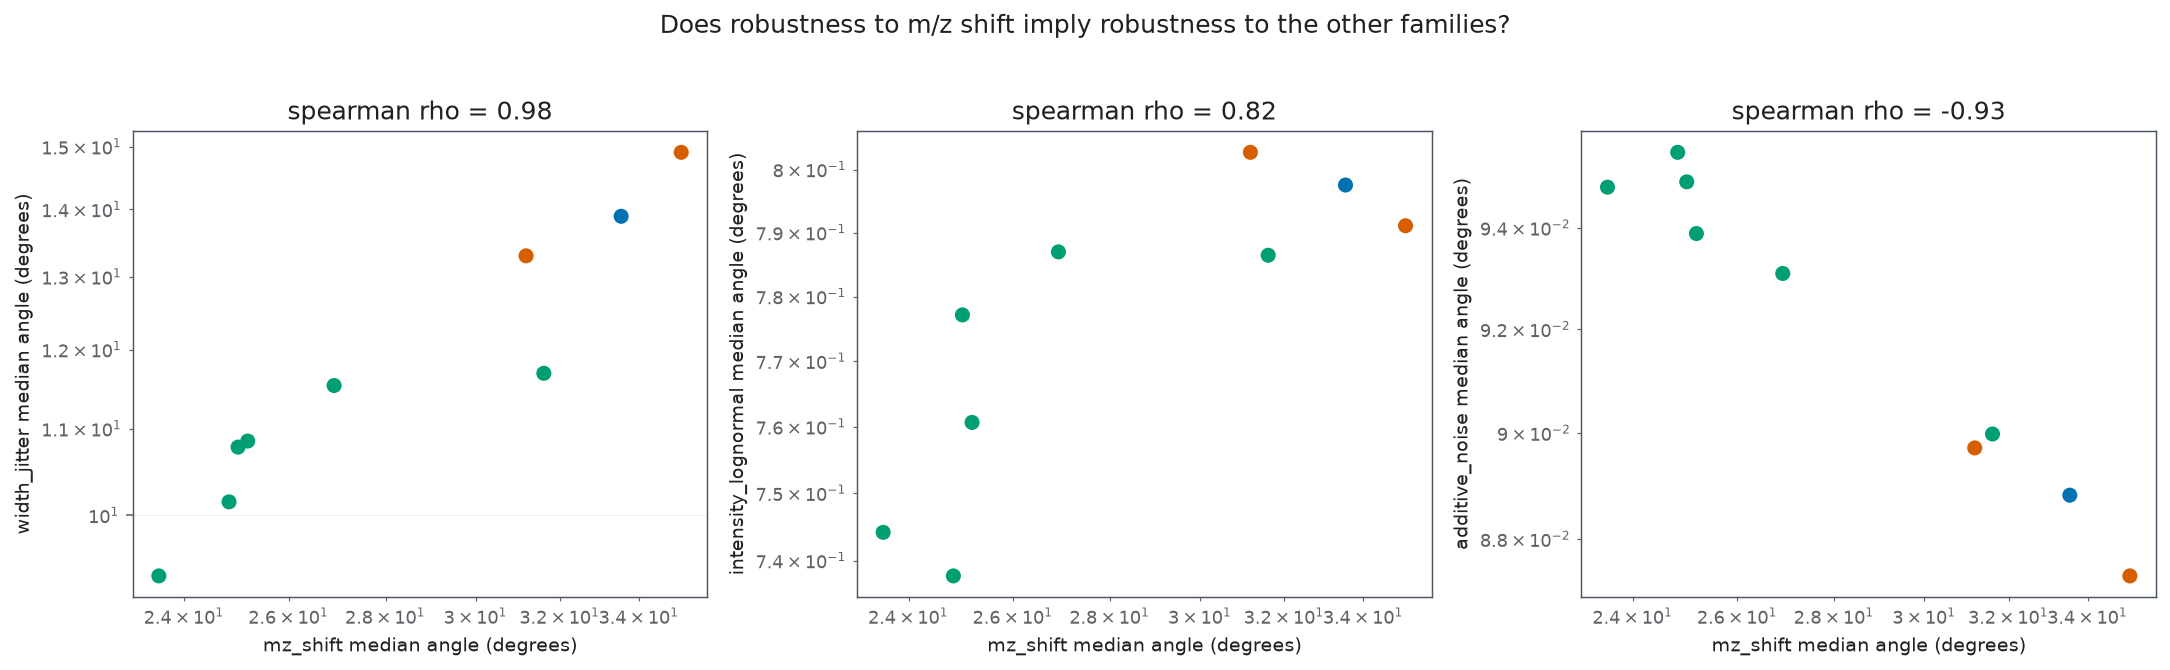

In [9]:
cell_medians = (
    response_frame.groupby(["cell_label", "perturbation"])["angle_degrees"].median().unstack()
    .reindex(SELECTED_CELLS)[list(perturbation.PERTURBATION_NAMES)]
)
display(cell_medians.round(4))

correlation = pd.DataFrame(
    [
        [spearmanr(cell_medians[left], cell_medians[right]).statistic for right in cell_medians.columns]
        for left in cell_medians.columns
    ],
    index=cell_medians.columns, columns=cell_medians.columns,
)
display(correlation.round(3))

others = [name for name in perturbation.PERTURBATION_NAMES if name != "mz_shift"]
figure, axes = plt.subplots(1, len(others), figsize=(5.2 * len(others), 4.6), dpi=theme.figure_dpi)
for axis, name in zip(np.atleast_1d(axes), others):
    axis.scatter(
        cell_medians["mz_shift"], cell_medians[name], s=60,
        color=[CELL_COLOR[cell] for cell in cell_medians.index], edgecolor="none",
    )
    rho = spearmanr(cell_medians["mz_shift"], cell_medians[name]).statistic
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set(xlabel="mz_shift median angle (degrees)", ylabel=f"{name} median angle (degrees)", title=f"spearman rho = {rho:.2f}")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Does robustness to m/z shift imply robustness to the other families?", y=1.03, fontsize=13)
figure.tight_layout()

## Chemical perturbations against the isotropic probe

### Methodology

#### Theoretical

`part_2` and `part_4` ranked these same models by their response to isotropic noise in the
ambient input space. That probe is neutral but unphysical. If it orders the cells the same
way the chemical families do, it is an adequate stand-in and the cheaper measurement
suffices in future work. If it does not, then conclusions drawn from isotropic sensitivity
alone do not transfer to the perturbations that actually occur, which would be a
methodological finding about the earlier notebooks rather than about the models.

#### Implementation

The isotropic responses are read from `part_4`'s persisted `angular_sensitivity.csv` at its
largest perturbation size, and correlated across cells with each chemical family's median
response. No model is re-encoded.

#### Figure descriptions

The table reports the Spearman correlation across the nine cells between the isotropic
response and each chemical family, with the number of cells contributing. High correlation
means the isotropic probe is a usable proxy for that family.

### Remarks

### Notes

In [10]:
ISOTROPIC_SOURCE = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_4_hinge_activation_refinement_results/angular_sensitivity.csv")
if ISOTROPIC_SOURCE.is_file():
    isotropic = pd.read_csv(ISOTROPIC_SOURCE)
    largest = isotropic["epsilon"].max()
    isotropic_by_cell = (
        isotropic.query("epsilon == @largest").groupby("cell_label")["mean_angle_degrees"].mean()
    )
    joined = cell_medians.join(isotropic_by_cell.rename("isotropic"), how="inner").dropna()
    proxy_frame = pd.DataFrame([
        {
            "perturbation": name,
            "spearman_rho_vs_isotropic": spearmanr(joined["isotropic"], joined[name]).statistic,
            "cells": len(joined),
        }
        for name in perturbation.PERTURBATION_NAMES
    ])
    display(proxy_frame.round(3))
else:
    proxy_frame = pd.DataFrame()
    print(f"Isotropic reference not found at {ISOTROPIC_SOURCE}; run part_4 first.")

,perturbation,spearman_rho_vs_isotropic,cells
0,mz_shift,0.950,9
1,width_jitter,0.967,9
2,intensity_lognormal,0.917,9
3,additive_noise,-0.950,9


## Reproducible artifacts

### Methodology

#### Implementation

Per-pixel responses, per-cell medians, amplitude curves, paired contrasts, transform
diagnostics and the proxy comparison are persisted, together with the pixel indices the
responses were measured on. Provenance records the campaigns, the perturbation settings,
the repeat and amplitude schedules, seeds, library versions, the commit and a hash of the
perturbation module.

### Remarks

### Notes

In [11]:
frames = {
    "perturbation_response": response_frame,
    "response_medians": median_by_run,
    "amplitude_curves": amplitude_frame,
    "baseline_contrasts": contrast_frame,
    "perturbation_diagnostics": diagnostics_frame,
    "cell_medians": cell_medians.reset_index(),
    "family_correlations": correlation.reset_index(),
    "isotropic_proxy": proxy_frame,
    "grid": grid_frame,
}
for name, frame in frames.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)
pd.DataFrame({"dataset_index": test_split.indices[response_selection]}).to_csv(ARTIFACT_DIR / "response_pixels.csv", index=False)

metadata = {
    "campaigns": CAMPAIGNS,
    "selected_cells": SELECTED_CELLS,
    "perturbations": list(perturbation.PERTURBATION_NAMES),
    "deterministic_perturbations": sorted(perturbation.DETERMINISTIC_PERTURBATIONS),
    "settings": {
        "shift_bins": PERTURBATION_SETTINGS.shift_bins,
        "extra_width_sigma": PERTURBATION_SETTINGS.extra_width_sigma,
        "base_width_sigma": PERTURBATION_SETTINGS.base_width_sigma,
        "lognormal_sigma": PERTURBATION_SETTINGS.lognormal_sigma,
        "noise_fraction": PERTURBATION_SETTINGS.noise_fraction,
    },
    "noise_repeats": NOISE_REPEATS,
    "amplitudes": list(AMPLITUDES),
    "response_pixels": int(len(response_selection)),
    "test_split_pixels": int(test_split.sampled),
    "sample_seed": SAMPLE_SEED,
    "models_evaluated": int(len(grid_frame)),
    "zero_amplitude_residual_degrees": float(zero_residual),
    "numpy": np.__version__,
    "torch": torch.__version__,
    "git_commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip(),
    "perturbations_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/analysis/autoencoder/latent/perturbations.py").read_bytes()).hexdigest(),
}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
logger.info("Wrote %s table(s) and provenance to %s", len(frames), ARTIFACT_DIR)
print(sorted(path.name for path in ARTIFACT_DIR.iterdir()))

2026-09-07 17:57:27,940 | INFO     | perturbation_response:41 | Wrote 9 table(s) and provenance to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_5_perturbation_response_results


['amplitude_curves.csv', 'baseline_contrasts.csv', 'cell_medians.csv', 'family_correlations.csv', 'grid.csv', 'isotropic_proxy.csv', 'metadata.json', 'perturbation_diagnostics.csv', 'perturbation_response.csv', 'response_medians.csv', 'response_pixels.csv']


## Results / Summary

### LLM

**The penalty works on the axis it was designed for, and this is the first notebook in the
campaign to show it doing anything.** Along the hinge weight ladder the median angular
response to a one-bin m/z shift falls from 33.5 degrees at the baseline to 23.5 at
$\lambda=8\times10^{-3}$, a 30% reduction that is monotone in weight apart from noise at the
last two rungs. Peak broadening falls from 13.9 to 9.4 degrees, a 33% reduction. Paired
against the baseline, the m/z-shift contrast separates from zero at $2\times10^{-3}$,
$4\times10^{-3}$ and $8\times10^{-3}$, and the broadening contrast at $8\times10^{-3}$ and
$10^{-2}$. The two control cells at $\lambda=10^{-5}$ show contrasts of $+0.98$ and $-2.20$
degrees with intervals spanning zero, which is what no effect looks like here.

**The robustness is not bought by collapsing the representation, and that is the campaign's
central result.** At $\lambda=8\times10^{-3}$ the latent trace is 98.7% of the baseline's
while the m/z-shift response is 70.2% of it; across the whole ladder the trace stays between
97.6% and 103.5% while the response falls steadily. `part_2` showed the Euclidean penalty
achieving robustness only through collapse, down to 2% of the baseline's trace. The input
metric change is what separates those two outcomes: the same family of penalty now reduces
sensitivity while leaving the code's variation intact.

**The effect is general, not m/z-specific, which does not match the argument that motivated
the metric change.** `part_0` selected Fisher-Rao because it tracked m/z-shift sensitivity
specifically and had no advantage on broadening. After training, the cells order almost
identically across families: Spearman correlation between m/z shift and broadening is 0.98
and between m/z shift and intensity noise 0.82. A model robust to one is robust to the
others. The trained penalty is compressing the encoder broadly rather than along the
direction the metric argument singled out, so the empirical success above is not evidence
for that argument's mechanism.

**Additive detector noise moves the other way.** Its contrast is positive at every ladder
rung, rising to $+0.006$ degrees, and its correlation with the other three families is
$-0.93$. The absolute size is small, from 0.089 to 0.096 degrees, but the sign is consistent
across the ladder and is a genuine trade: the configurations most robust to geometric
perturbation are slightly more responsive to amplitude noise.

**A caveat that limits the mechanistic reading.** The m/z shift places on average 47% of the
perturbed mass, and in the worst pixel 100%, into bins that were empty in the original
spectrum. A perturbation that far off the original support is outside what any
support-respecting local measure, the Fisher-Rao one included, can bound. The penalty
nonetheless reduces the response to it, which is consistent with the general-compression
reading above and inconsistent with the response being controlled by the trained local
geometry in that direction.

**Methodological finding about the earlier notebooks.** The isotropic probe used in `part_2`
and `part_4` orders these nine cells almost exactly as the chemical families do: Spearman
0.95 against m/z shift, 0.97 against broadening, 0.92 against intensity noise, and $-0.95$
against additive noise. The cheap neutral probe is therefore an adequate proxy for the
expensive physical ones on this model set, and the earlier notebooks' sensitivity
conclusions transfer.

**Pipeline check.** The zero-amplitude angular residual is $9.7\times10^{-6}$ degrees, so the
measurement introduces no spurious displacement and the amplitude sweep starts from a true
zero.

**What this changes about the campaign's verdict.** `part_4` left two readings open for the
absent prediction gain. This notebook removes one form of doubt: the penalty is not inert,
it measurably does what a contractive regularizer is supposed to do, and it does so without
the collapse that made the Euclidean version useless. The robustness simply does not convert
into in-distribution prediction quality. That narrows the remaining question to whether the
robustness pays off under evaluation conditions that differ from training, which no
measurement in this campaign addresses.

### Person